In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [3]:
loan=pd.read_csv("loan approval data.csv")
df=pd.read_csv("loan approval data.csv")

In [4]:
loan.info()
loan["Employment_Status"].nunique
loan.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [5]:
value=["Applicant_ID","Applicant_Income","Coapplicant_Income","Age","Dependents","Credit_Score",
       "Existing_Loans","DTI_Ratio","Savings","Collateral_Value","Loan_Amount","Loan_Term",
       ]
category=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Education_Level","Gender","Employer_Category","Loan_Approved"]


In [6]:
for val in value:
    mean=loan[val].mean()
    loan[val]=loan[val].fillna(mean)

for cat in category:
    mode=loan[cat].mode()[0]
    loan[cat]=loan[cat].fillna(mode)

  

In [7]:
loan

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [8]:
categorical_cols=df.select_dtypes(include=["str"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns


In [9]:

from sklearn.impute import SimpleImputer
num_imputer=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imputer.fit_transform(df[numerical_cols])
cat_imputer=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imputer.fit_transform(df[categorical_cols])


In [10]:
df

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


Text(0.5, 1.0, 'Is Loan Approved Or Not')

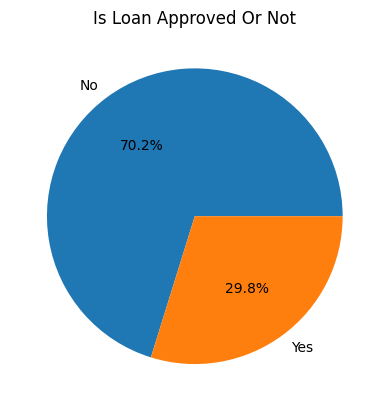

In [11]:
category=loan["Loan_Approved"].value_counts()
plt.pie(category,labels=category.index,autopct="%1.1f%%")
plt.title("Is Loan Approved Or Not")

[Text(0, 0, '621'), Text(0, 0, '379')]

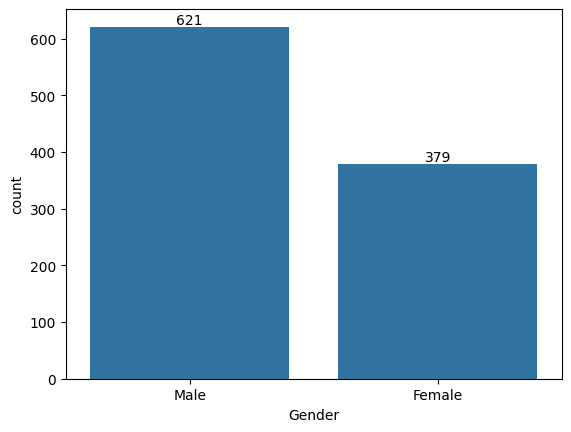

In [12]:
gender_counts=loan["Gender"].value_counts()
gender_counts
ax=sns.barplot(gender_counts)
ax.bar_label(ax.containers[0])



[Text(0, 0, '722'), Text(0, 0, '278')]

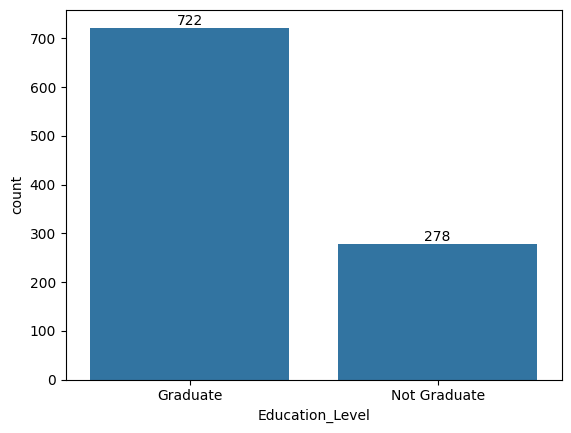

In [13]:
edu_counts=loan["Education_Level"].value_counts()
ax=sns.barplot(edu_counts)
ax.bar_label(ax.containers[0])


[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

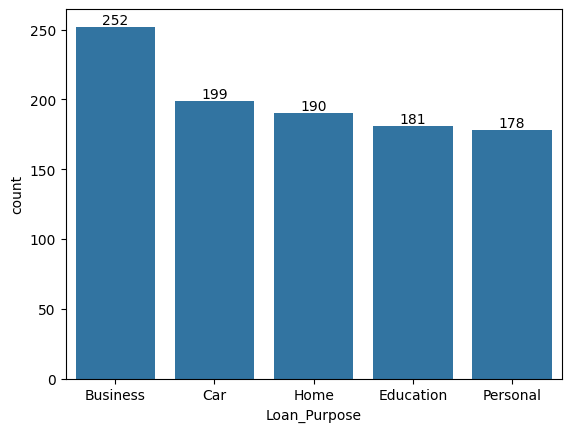

In [14]:
loan_pur_count=loan["Loan_Purpose"].value_counts()
ax=sns.barplot(loan_pur_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

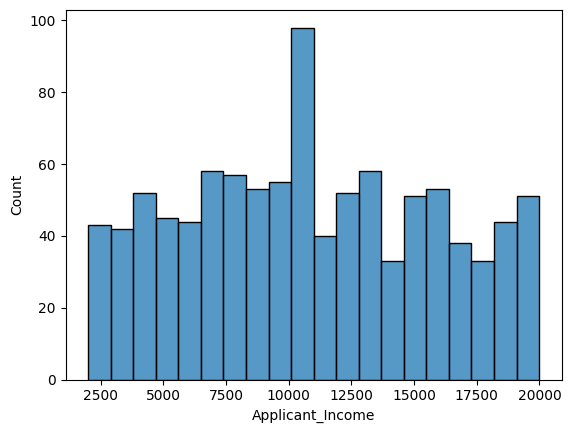

In [15]:
sns.histplot(
    data=loan,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

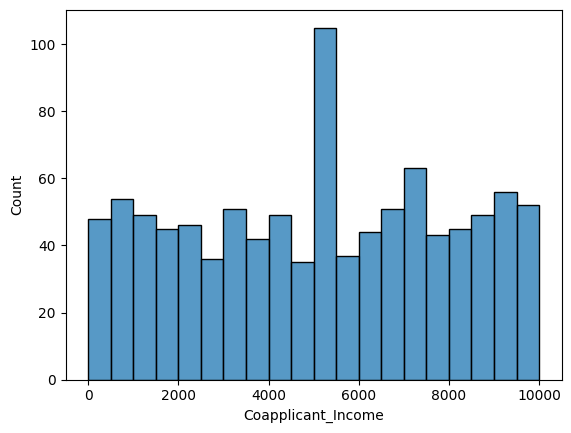

In [16]:
sns.histplot(
    data=loan,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

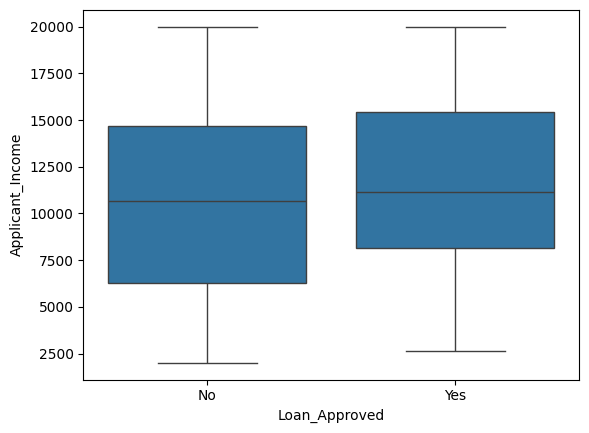

In [17]:
sns.boxplot(
    data=loan,
    y="Applicant_Income",
    x="Loan_Approved"
)

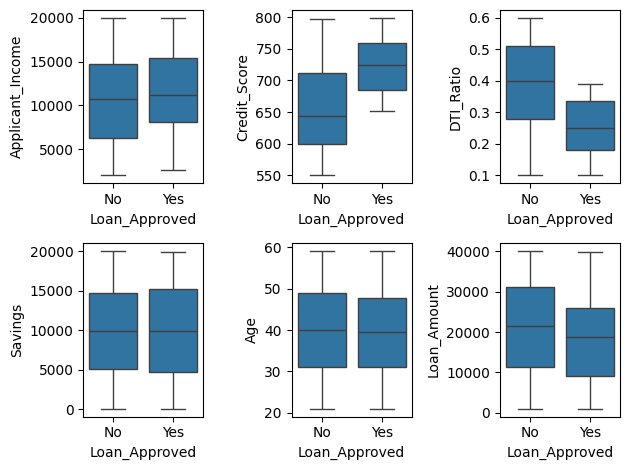

In [18]:
fig,axis=plt.subplots(2,3)
sns.boxplot(ax=axis[0,0],data=loan,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axis[0,1],data=loan,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axis[0,2],data=loan,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axis[1,0],data=loan,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axis[1,1],data=loan,x="Loan_Approved",y="Age")
sns.boxplot(ax=axis[1,2],data=loan,x="Loan_Approved",y="Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

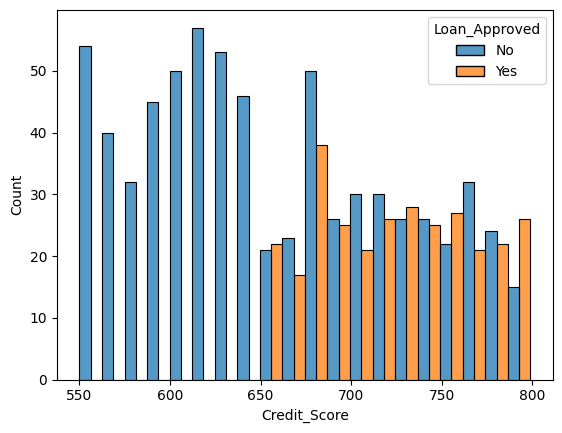

In [19]:
sns.histplot(
    data=loan,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

In [20]:
loan=loan.drop(columns="Applicant_ID")

In [21]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [22]:
loan.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [27]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
one_cols=["Employer_Category","Gender","Property_Area","Loan_Purpose","Marital_Status","Employment_Status"]
le=LabelEncoder()
loan["Loan_Approved"]=le.fit_transform(loan["Loan_Approved"])
loan["Education_Level"]=le.fit_transform(loan["Education_Level"])
loan


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,0
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,0
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,0
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,1


In [32]:
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(loan[one_cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(one_cols),index=loan.index)
loan=pd.concat([loan.drop(columns=one_cols),encoded_df],axis=1)

In [33]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

In [40]:
numerical_cols=loan.select_dtypes(include="number")
corr_matrix=numerical_cols.corr()
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.004845,-0.036260,-0.083398,0.032794,0.074209,-0.031234,0.010057,-0.000863,0.005609,0.001419
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,-0.010058,0.030045,-0.020148,0.028000,0.016022,0.059549,-0.011431,-0.013517,-0.010462,0.023114
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,0.003100,-0.025661,-0.025521,-0.006283,0.029865,0.037293,0.009162,-0.000167,-0.011743,-0.009866
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.032278,0.024082,-0.043685,-0.044642,0.027343,-0.005785,-0.011410,-0.034611,0.079136,0.000396
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,-0.006946,0.004445,-0.030142,0.026013,-0.008658,0.015324,0.056176,-0.016627,-0.035896,-0.008344
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.053971,0.035629,-0.025228,-0.010035,0.001777,0.023212,0.018010,-0.004462,0.042772,-0.012356
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.044898,-0.006156,-0.020907,0.040432,-0.014125,-0.036648,-0.014850,0.031658,-0.043904,0.022318
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.005438,0.016833,-0.009133,0.032558,-0.012217,-0.028948,-0.004131,0.022435,0.000668,0.006304
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.020061,0.007975,0.031112,0.040406,-0.050975,-0.007120,0.018450,-0.019882,0.000119,-0.041632
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,0.040206,-0.050076,-0.006788,-0.006119,-0.000930,0.032498,0.004683,-0.003266,-0.072972,-0.007407


In [41]:
numerical_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

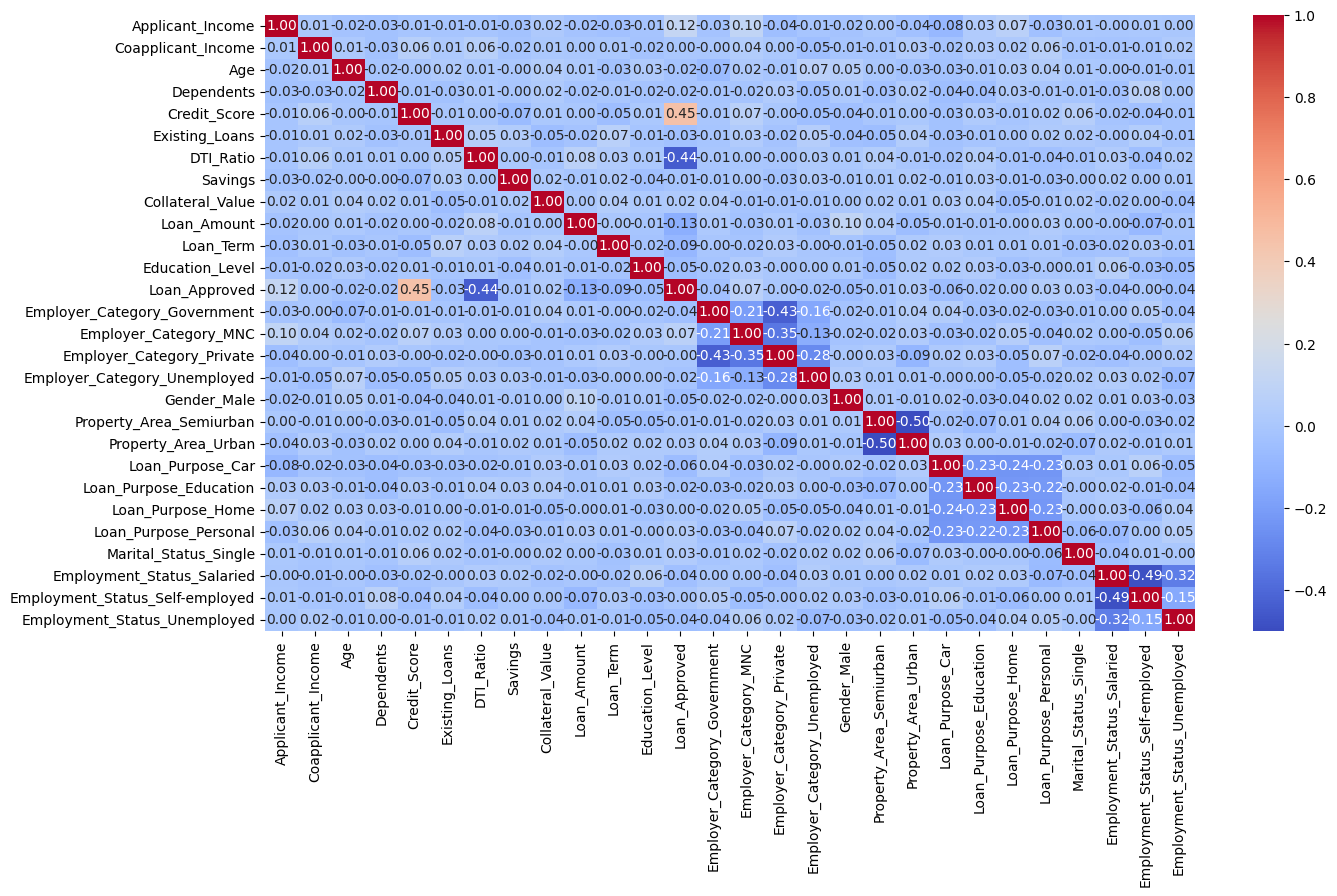

In [45]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [48]:
X=loan.drop(columns="Loan_Approved")
y=loan["Loan_Approved"]

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
scalar=StandardScaler()
X_train_Scaled=scalar.fit_transform(X_train)
X_test_Scaled=scalar.transform(X_test)

In [55]:
model=LogisticRegression()
model.fit(X_train_Scaled,y_train)
y_pred=model.predict(X_test_Scaled)


In [59]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [60]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

accuracy_score: 0.865
precision_score: 0.7833333333333333
recall_score: 0.7704918032786885
f1_score: 0.7768595041322314
confusion_matrix: [[126  13]
 [ 14  47]]


In [63]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={"n_neighbors":[3,5,7,9]},
    scoring="precision",
    cv=5
)

In [64]:
grid.fit(X_train_Scaled,y_train)
y_pred=grid.predict(X_test_Scaled)


In [65]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

accuracy_score: 0.76
precision_score: 0.6585365853658537
recall_score: 0.4426229508196721
f1_score: 0.5294117647058824
confusion_matrix: [[125  14]
 [ 34  27]]


In [69]:
ne_model=GaussianNB()
ne_model.fit(X_train_Scaled,y_train)
y_pred=ne_model.predict(X_test_Scaled)

In [70]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

accuracy_score: 0.865
precision_score: 0.8035714285714286
recall_score: 0.7377049180327869
f1_score: 0.7692307692307693
confusion_matrix: [[128  11]
 [ 16  45]]


In [71]:
loan

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


In [73]:
loan["DTI_Ratio_Sq"]=loan["DTI_Ratio"]**2
loan["Credit_Score_Sq"]=loan["Credit_Score"]**2
X=loan.drop(columns=["DTI_Ratio","Credit_Score","Loan_Approved"])
y=loan["Loan_Approved"]

In [74]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
scalar=StandardScaler()
X_train_Scaled=scalar.fit_transform(X_train)
X_test_Scaled=scalar.transform(X_test)

In [77]:
model=LogisticRegression()
model.fit(X_train_Scaled,y_train)
y_pred=model.predict(X_test_Scaled)

In [78]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

accuracy_score: 0.875
precision_score: 0.7903225806451613
recall_score: 0.8032786885245902
f1_score: 0.7967479674796748
confusion_matrix: [[126  13]
 [ 12  49]]


In [80]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={"n_neighbors":[3,5,7,9]},
    scoring="precision",
    cv=5
)
grid.fit(X_train_Scaled,y_train)
y_pred=grid.predict(X_test_Scaled)

In [81]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

accuracy_score: 0.77
precision_score: 0.6666666666666666
recall_score: 0.4918032786885246
f1_score: 0.5660377358490566
confusion_matrix: [[124  15]
 [ 31  30]]


In [82]:
ne_model=GaussianNB()
ne_model.fit(X_train_Scaled,y_train)
y_pred=ne_model.predict(X_test_Scaled)

In [83]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

accuracy_score: 0.865
precision_score: 0.7833333333333333
recall_score: 0.7704918032786885
f1_score: 0.7768595041322314
confusion_matrix: [[126  13]
 [ 14  47]]
